# Librerías básicas para computación científica en Python

En el ecosistema de ciencia de datos, inteligencia artificial y análisis numérico en Python, existen tres librerías fundamentales que se utilizan de forma conjunta: **NumPy**, **SciPy** y **Matplotlib**. Cada una cumple un rol específico dentro del flujo de trabajo científico y analítico.

---

# NumPy (`numpy`)

**NumPy** es la biblioteca central para la **computación numérica en Python**. Proporciona estructuras de datos eficientes para manejar grandes volúmenes de números y operaciones matemáticas complejas.

Su función principal es ofrecer **arrays multidimensionales optimizados**, que permiten realizar cálculos vectorizados mucho más rápidos que utilizando estructuras nativas del lenguaje.

Además, incluye herramientas para:

- Manipulación de matrices y vectores
- Álgebra lineal
- Operaciones matemáticas avanzadas
- Estadística básica
- Generación de números aleatorios
- Transformaciones matemáticas sobre grandes conjuntos de datos

Muchas bibliotecas de inteligencia artificial, aprendizaje automático y análisis de datos están construidas sobre NumPy.

---

# SciPy (`scipy`)

**SciPy** es una biblioteca que amplía las capacidades de NumPy proporcionando **algoritmos científicos y matemáticos avanzados**.

Está diseñada para resolver problemas más complejos en áreas como la ingeniería, la física, la estadística y la investigación científica.

Entre sus capacidades se incluyen:

- Optimización matemática
- Integración numérica
- Interpolación
- Procesamiento de señales
- Estadística avanzada
- Álgebra lineal especializada
- Resolución de ecuaciones diferenciales

SciPy utiliza NumPy como base para las estructuras de datos y añade capas de algoritmos científicos más sofisticados.

---

# Matplotlib (`matplotlib.pyplot`)

**Matplotlib** es una biblioteca dedicada a la **visualización de datos** en Python.

Permite transformar datos numéricos en representaciones gráficas que facilitan el análisis, la interpretación y la comunicación de resultados.

Con Matplotlib es posible crear diferentes tipos de visualizaciones, como:

- Gráficos de líneas
- Diagramas de dispersión
- Histogramas
- Gráficos de barras
- Visualizaciones estadísticas
- Representaciones científicas personalizadas

El módulo `pyplot` proporciona una interfaz sencilla para generar gráficos de forma rápida y controlada.

---

# Relación entre las tres librerías
Estas tres herramientas forman parte del **núcleo del ecosistema científico de Python** y suelen utilizarse de manera complementaria:

- **NumPy** gestiona y procesa los datos numéricos.
- **SciPy** aplica métodos matemáticos y científicos avanzados.
- **Matplotlib** permite visualizar los resultados de forma gráfica.

Este conjunto de librerías constituye una base fundamental para disciplinas como:

- Ciencia de datos
- Inteligencia artificial
- Machine learning
- Análisis estadístico
- Simulación científica
- Ingeniería computacional

In [3]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

## `make_circles` de scikit-learn

La función `from sklearn.datasets import make_circles` se utiliza para generar un conjunto de datos artificial con forma de círculos concéntricos, ideal para problemas de clasificación en machine learning.

### ¿Para qué se usa?

- Probar algoritmos de clasificación
- Demostrar problemas no lineales
- Practicar con modelos de machine learning
- Entrenar redes neuronales o SVM

### Características del dataset

- Genera dos clases:
    - Puntos en un círculo interno
    - Puntos en un círculo externo

Este tipo de datos es útil para mostrar que los modelos lineales no pueden separar bien las clases, mientras que los modelos no lineales sí pueden hacerlo.

In [4]:
"""Parámetros importantes:

n_samples → número de puntos

noise → ruido en los datos

factor → tamaño del círculo interior"""

from sklearn.datasets import make_circles



In [5]:
#Crear datos artificiales, donde buscaremos clasificar dos anillos concèntricos de datos.
X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

In [6]:
# Resolucion del mapa de predicciones.
res = 100

In [7]:
#Coordenadas de los puntos a predecir.
_x0 = np.linspace(-1.5, 1.5, res)
_x1 = np.linspace(-1.5, 1.5, res)


In [8]:
# Input con cada combo de coordenadads del mapa de predicciones.
_px = np.array(np.meshgrid(_x0, _x1)).T.reshape(-1, 2)

In [9]:
# Objeto vacío a 0.5 del mapa de predicciones.
_py = np.zeros((res, res)) + 0.5

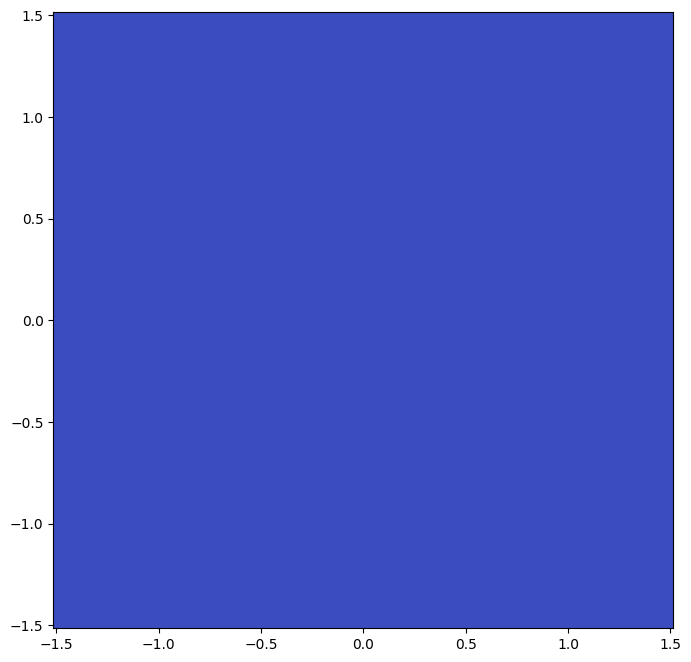

In [14]:
# Visualización de los datos y el mapa de predicciones.
plt.figure(figsize=(8, 8))
plt.pcolormesh(_x0, _x1, _py, cmap="coolwarm", shading="auto")

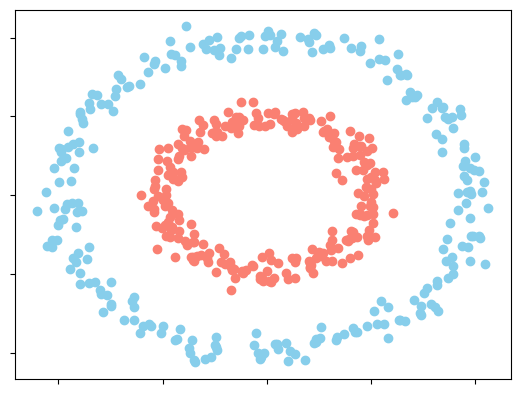

In [15]:
# Visualización de la nube de datos.
plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
plt.scatter(X[Y == 1,0], X[Y == 1,1], c="salmon")

plt.tick_params(labelbottom=False, labelleft=False)

# <--------- USO DE TENSORFLOW ----------------->

### Importamos las librerías necesarias
TensorFlow es una biblioteca de código abierto para computación numérica y aprendizaje automático. Se usa para construir, entrenar y desplegar modelos (redes neuronales, regresión, clasificación, etc.) de forma escalable.

Cómo funciona, a grandes rasgos:

Define un grafo de operaciones sobre tensores (arrays multidimensionales).
Propaga datos hacia adelante (forward) para calcular salidas/pérdidas.
Usa retropropagación para calcular gradientes de parámetros.
Optimiza parámetros (pesos/bias) con optimizadores (SGD, Adam, etc.).
Permite ejecutar en CPU, GPU y TPU, y exportar modelos para producción.


In [10]:
import tensorflow as tf
print(tf.__version__)
import numpy as np
import matplotlib.pyplot as plt

2.21.0


In [11]:
from matplotlib import animation   # Para crear animaciones
from IPython.display import display, HTML    # Para mostrar animaciones en Jupyter Notebook

tf.compat.v1.disable_eager_execution()  # Deshabilitar ejecución ansiosa para usar TF1 style

#### En TF1 los `placeholder` son “entradas por la puerta” del grafo: reservan un tensor donde meter datos cuando ejecutas `sess.run(...)`, sin fijar valores al construir el grafo.

- **`iX`** es donde alimentarás los features (entrada) en cada batch.
- **`iY`** es donde alimentarás las etiquetas/targets.

Así separas construcción del modelo (variables, operaciones) de los datos reales que vienen en el entrenamiento/inferencia.

In [12]:
iX = tf.compat.v1.placeholder(tf.float32, shape=[None, X.shape[1]])
iY = tf.compat.v1.placeholder(tf.float32, shape=[None])

In [13]:
lr = 0.01 # Learning rate
nn = [2, 16, 8, 1] # Neuronas por capa (input, hidden1, hidden2, output) [2 inputs, 16 neuronas en la primera capa oculta, 8 en la segunda capa oculta, 1 output]

In [14]:
# Si nn = [2, 16, 8, 1], entonces:
# w1 shape = [2, 16] (2 inputs, 16 neuronas en la primera capa oculta)
# b1 shape = [16] (un bias por cada neurona en la primera capa oculta)
# w2 shape = [16, 8] (16 neuronas en la primera capa oculta, 8 neuronas en la segunda capa oculta)
# b2 shape = [8] (un bias por cada neurona en la segunda capa oculta)
# w3 shape = [8, 1] (8 neuronas en la segunda capa oculta, 1 output)
# b3 shape = [1] (un bias para el output)

# Capa 1
w1 = tf.Variable(tf.random.normal([nn[0], nn[1]]), name="weights_1")
b1 = tf.Variable(tf.random.normal([nn[1]]))

l1 = tf.nn.relu(tf.add(tf.matmul(iX, w1), b1))  # Salida de la capa 1 con activación ReLU

# Capa 2
w2 = tf.Variable(tf.random.normal([nn[1], nn[2]]), name="weights_2")
b2 = tf.Variable(tf.random.normal([nn[2]]))

l2 = tf.nn.relu(tf.add(tf.matmul(l1, w2), b2))  # Salida de la capa 2 con activación ReLU

# Capa 3 (output)
w3 = tf.Variable(tf.random.normal([nn[2], nn[3]]), name="weights_3")
b3 = tf.Variable(tf.random.normal([nn[3]]))

# Vector de predicciones  Y
pY = tf.nn.sigmoid(tf.add(tf.matmul(l2, w3), b3))[:, 0]  # Predicción de la capa 3 (output) y aplanar a 1D

In [15]:
# Evaluacion de las predicciones
loss = tf.reduce_mean(tf.square(pY - iY))  # MSE entre predicciones y etiquetas reales

In [16]:
# Optimizador para minimizar la función de pérdida
optimizer = tf.compat.v1.train.GradientDescentOptimizer(learning_rate=lr).minimize(loss)

In [17]:
n_steps = 1000 # Número de pasos de entrenamiento

iPY = []  # Lista para almacenar las predicciones en cada paso para la animación

In [36]:
# Sesion de TensorFlow para entrenar la red
with tf.compat.v1.Session() as sess:
    #Inicializamos todos los parametros (pesos y biases)
    sess.run(tf.compat.v1.global_variables_initializer())
    
    #Iteramos el proceso de entrenamiento por n_steps
    for step in range(n_steps):
        
        #Evaluamos el optimizador, la funcion de coste y al tensor de predicciones pY, alimentando los datos de entrenamiento (X, Y)
        _, _loss, _pY = sess.run([optimizer, loss, pY], feed_dict={iX: X, iY: Y})
        
        #Cada 25 interacciones, imprimimos metricas.
        if step %25 == 0:
        
            #Calculo del accuracy (predicciones correctas sobre total de predicciones)
            acc = np.mean(np.round(_pY) == Y)
            
            #Imprimimos el paso, la perdida y la accuracy
            print(f"Step: {step}, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)")
            
            #Obtenemos las predicciones del mapa de predicciones (_px) y las almacenamos en la lista iPY para la animación
            _iPY = sess.run(pY, feed_dict={iX: _px}).reshape((res, res))
            
            # Lo guardamos para la animación
            iPY.append(_iPY)

Step: 0, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 25, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 50, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 75, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 100, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 125, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 150, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 175, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 200, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 225, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 250, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 275, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 300, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 325, '/', n_steps, ' - Loss = ', _loss, ' - Accuracy = ', acc)
Step: 350, '/', n_steps, ' - Loss = ', 

Creando animación...


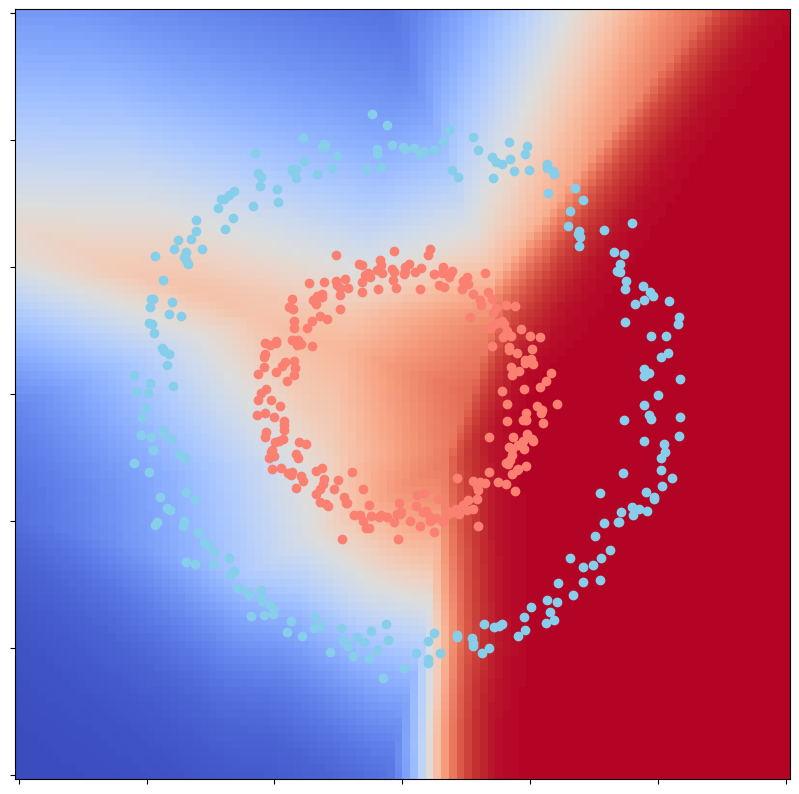

In [22]:
# <-------- Codigo de animación --------->
ims = []

fig = plt.figure(figsize=(10, 10))

print("Creando animación...")

for fr in range(len(iPY)):
    
    im = plt.pcolormesh(_x0, _x1, iPY[fr], cmap="coolwarm", animated=True)
    
    #Visualización de la nube de datos.
    plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
    plt.scatter(X[Y == 1,0], X[Y == 1,1], c="salmon")
    
    # plt.title(Resultados del entrenamiento, step=fr*25)
    plt.tick_params(labelbottom=False, labelleft=False)
    
    ims.append([im])
    
    ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
    
    HTML(ani.to_html5_video())

## Keras 
Keras es una biblioteca de alto nivel para construir y entrenar redes neuronales, que se ejecuta sobre TensorFlow. Proporciona una interfaz fácil de usar para definir modelos de aprendizaje profundo, lo que facilita la creación de redes neuronales complejas con pocas líneas de código. Keras es especialmente popular por su simplicidad y flexibilidad, lo que la convierte en una excelente opción tanto para principiantes como para expertos en aprendizaje automático.

In [1]:
import tensorflow as tf
import tensorflow.keras as kr   # Importamos Keras desde TensorFlow

from IPython.display import display, HTML    # Para mostrar animaciones en Jupyter Notebook

In [2]:
lr = 0.01 # Learning rate
nn = [2, 16, 8, 1] # Neuronas por capa (input, hidden1, hidden2, output) [2 inputs, 16 neuronas en la primera capa oculta, 8 en la segunda capa oculta, 1 output]

In [3]:
# Creamos el objeto que va a contener la red neuronal, indicando el tipo de modelo (secuencial) y el nombre del modelo.
model = kr.Sequential()

In [4]:
#Añadimos la primera capa
l1 = model.add(kr.layers.Dense(nn[1], activation='relu', input_shape=(nn[0],)))

#Añadimos la segunda capa
l2 = model.add(kr.layers.Dense(nn[2], activation='relu'))

#Añadimos la tercera capa
l3 = model.add(kr.layers.Dense(nn[3], activation='sigmoid'))

In [16]:
model.compile(
    loss='mse',
    optimizer=kr.optimizers.SGD(learning_rate=0.05),
    metrics=['acc']
)

model.fit(X, Y, epochs=100)

Epoch 1/100


16/16 [==============================] - 1s 3ms/step - loss: 0.2498 - acc: 0.5360
Epoch 2/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2476 - acc: 0.5140
Epoch 3/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2457 - acc: 0.5000
Epoch 4/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2438 - acc: 0.5100
Epoch 5/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2420 - acc: 0.5380
Epoch 6/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2403 - acc: 0.5720
Epoch 7/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2385 - acc: 0.6280
Epoch 8/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2366 - acc: 0.7060
Epoch 9/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2347 - acc: 0.7620
Epoch 10/100
16/16 [==============================] - 0s 2ms/step - loss: 0.2327 - acc: 0.7560
Epoch 11/100
16/16 [==============================] - 0s 

## Sklearn(Scikit-learn)

Sklearn, también conocido como scikit-learn, es una biblioteca de aprendizaje automático en Python que proporciona herramientas para la construcción y evaluación de modelos de machine learning. Ofrece una amplia gama de algoritmos para clasificación, regresión, clustering y reducción de dimensionalidad, así como funciones para preprocesamiento de datos, selección de características y evaluación de modelos. Sklearn es ampliamente utilizado en la comunidad de ciencia de datos debido a su facilidad de uso y su integración con otras bibliotecas como NumPy y Pandas.

In [10]:
import sklearn as sk # Importamos la biblioteca de machine learning scikit-learn
import sklearn.neural_network  # Importamos el módulo de redes neuronales de scikit-learn

from IPython.display import display, HTML    # Para mostrar animaciones en Jupyter Notebook

lr = 0.01 # Learning rate
nn = [2, 16, 8, 1] # Neuronas por capa (input, hidden1, hidden2, output) [2 inputs, 16 neuronas en la primera capa oculta, 8 en la segunda capa oculta, 1 output]

# Creamos el modelo de red neuronal multicapa
clf = sk.neural_network.MLPRegressor(solver='sgd',
                                     learning_rate_init=lr,
                                     hidden_layer_sizes=tuple(nn[1:]),
                                     verbose=True,
                                     n_iter_no_change=1000,
                                     batch_size = 64)

#Entrenamos el modelo con los datos de entrenamiento (X, Y)
clf.fit(X, Y)

Iteration 1, loss = 0.14238280
Iteration 2, loss = 0.12166023
Iteration 3, loss = 0.10751744
Iteration 4, loss = 0.10180851
Iteration 5, loss = 0.09468709
Iteration 6, loss = 0.08814318
Iteration 7, loss = 0.08189748
Iteration 8, loss = 0.07645111
Iteration 9, loss = 0.07149477
Iteration 10, loss = 0.06732114
Iteration 11, loss = 0.06331347
Iteration 12, loss = 0.05931445
Iteration 13, loss = 0.05512487
Iteration 14, loss = 0.05211792
Iteration 15, loss = 0.04681887
Iteration 16, loss = 0.04250768
Iteration 17, loss = 0.03783502
Iteration 18, loss = 0.03285099
Iteration 19, loss = 0.02819641
Iteration 20, loss = 0.02430547
Iteration 21, loss = 0.01998266
Iteration 22, loss = 0.01698698
Iteration 23, loss = 0.01446410
Iteration 24, loss = 0.01274031
Iteration 25, loss = 0.01141477
Iteration 26, loss = 0.01056509
Iteration 27, loss = 0.01002580
Iteration 28, loss = 0.00952239
Iteration 29, loss = 0.00928016
Iteration 30, loss = 0.00895305
Iteration 31, loss = 0.00876459
Iteration 32, los

c:\Users\drale\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
